In [72]:
import pandas as pd

In [73]:
df=pd.read_csv('Housing.csv')

In [74]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [75]:
df.tail()


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
540,1820000,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,1767150,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,1750000,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,1750000,2910,3,1,1,no,no,no,no,no,0,no,furnished
544,1750000,3850,3,1,2,yes,no,no,no,no,0,no,unfurnished


In [76]:
df.shape

(545, 13)

In [77]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [78]:
df.describe()


,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


Quick health check — 545 rows, 13 cols, zero missing values. Clean data, rare win.

--- now checking outlier in the data and removing them 

In [82]:
numerical_cols = ['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'parking']

for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f"Outliers in {col}: {len(outliers)}")
    
    # Remove outliers
    df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

print(f"\nShape after outlier removal: {df.shape}")


Outliers in price: 15
Outliers in area: 13
Outliers in bedrooms: 11
Outliers in bathrooms: 123
Outliers in stories: 12
Outliers in parking: 6

Shape after outlier removal: (365, 13)


now  working on categorical column and convert yes/no into 0 and 1


In [83]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
column=["mainroad","guestroom","basement","hotwaterheating","airconditioning","prefarea","furnishingstatus"]
for cols in column:
    df[cols] = le.fit_transform(df[cols])


visualising y on the basis of x

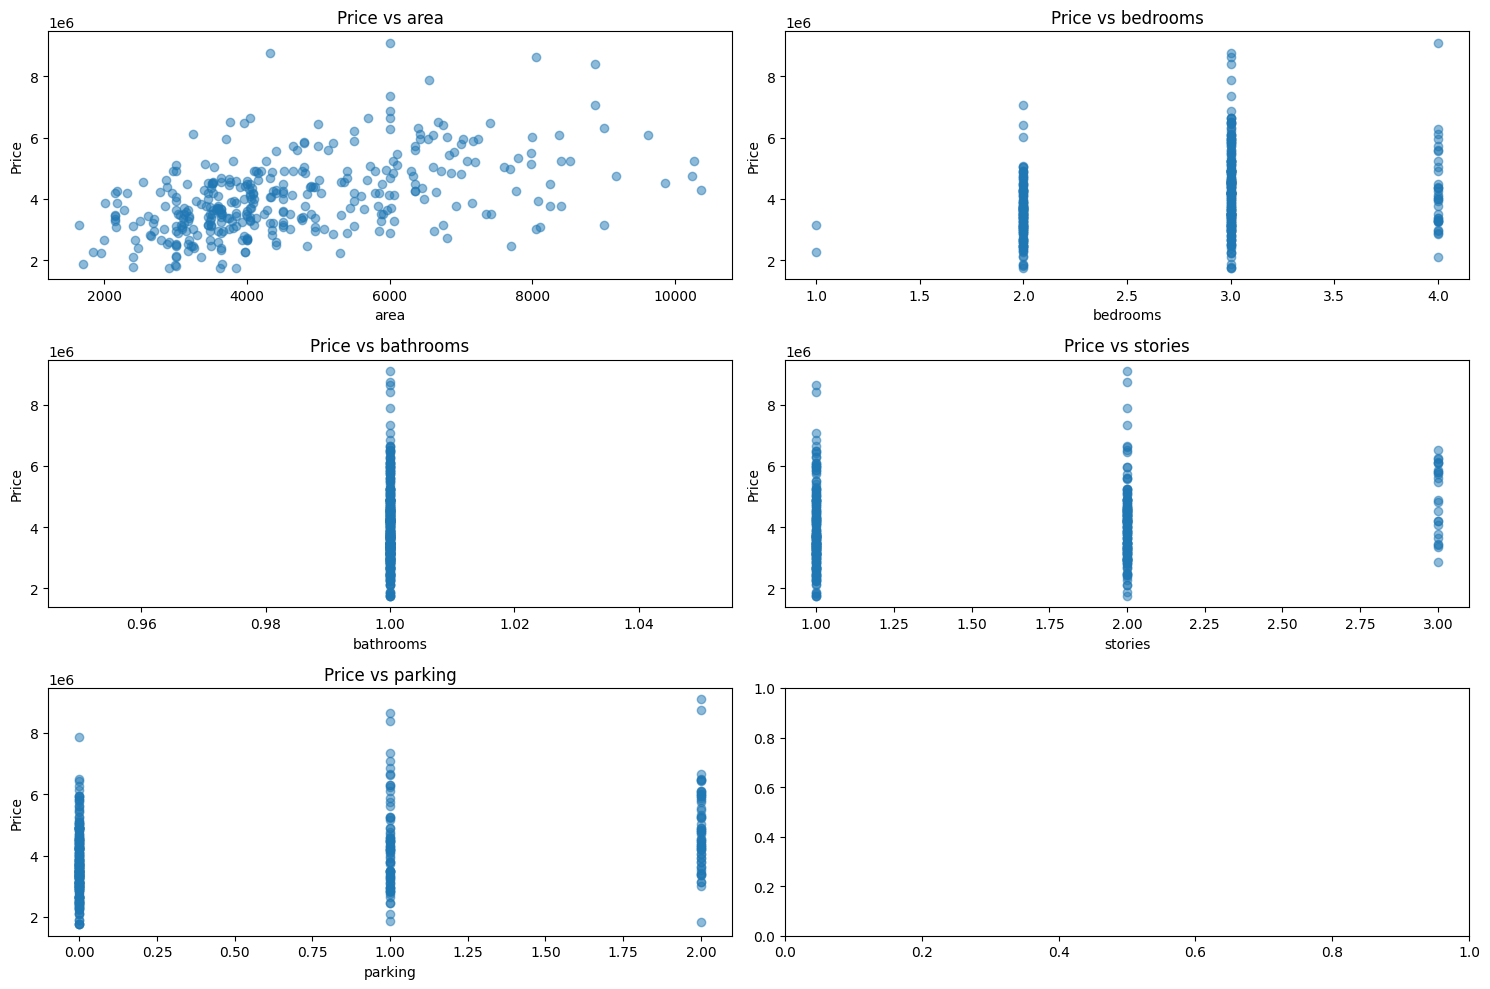

In [84]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(3, 2, figsize=(15, 10))
axes = axes.ravel()

features = ['area', 'bedrooms', 'bathrooms', 'stories', 'parking']

for idx, feature in enumerate(features):
    axes[idx].scatter(df[feature], df['price'], alpha=0.5)
    axes[idx].set_xlabel(feature)
    axes[idx].set_ylabel('Price')
    axes[idx].set_title(f'Price vs {feature}')

plt.tight_layout()
plt.show()

creating a new feature price per square fit

In [101]:
df['price_per_sqft'] = df['price'] / df['area']


x have all features on the basis we predict our target y

In [ ]:
x=df.drop('price',axis=1)
y=df['price']


In [87]:
from sklearn.model_selection import train_test_split

In [ ]:
xtrain,xtest,ytrain,ytest=train_test_split(x,y,test_size=0.2,random_state=42)

In [92]:
from sklearn.preprocessing import StandardScaler

# Standardize features: zero mean, unit variance
# Critical for Linear Regression — ensures features on comparable scales
# Fit on train only; transform both to prevent data leakage

In [96]:
scaler = StandardScaler()
xtrain_scaled = scaler.fit_transform(xtrain)
Xtest_scaled = scaler.transform(xtest)

In [ ]:
from sklearn.linear_model import LinearRegression

In [98]:
from sklearn.linear_model import LinearRegression

LinearRegression_Model = LinearRegression()
LinearRegression_Model.fit(xtrain_scaled, ytrain)
predict = LinearRegression_Model.predict(Xtest_scaled)

In [99]:
from sklearn.metrics import mean_squared_error,mean_absolute_error, r2_score
import numpy as np

mse = mean_squared_error(ytest,predict)
rmse=np.sqrt(mse)

mae = mean_absolute_error(ytest, predict)
r2 = r2_score(ytest, predict)

print("MSE:", mse)
print("RMSE:",rmse)
print("MAE:", mae)
print("R2 Score:", r2)

MSE: 586676606817.3192
RMSE: 765948.1750205553
MAE: 503245.29740989977
R2 Score: 0.8839314564398745


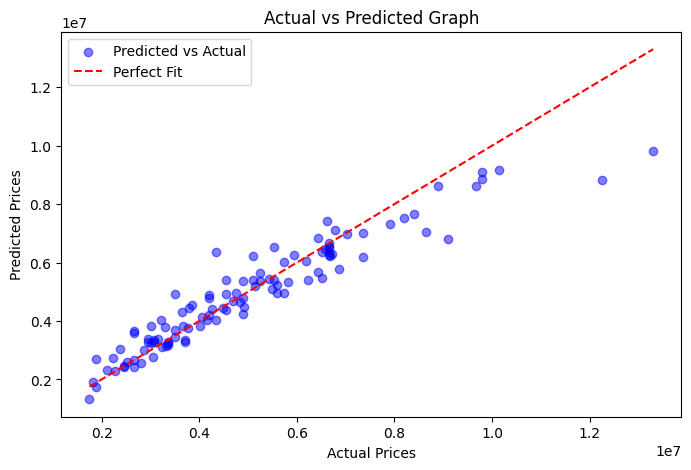

In [100]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.scatter(ytest, predict, color="blue", alpha=0.5, label="Predicted vs Actual")

plt.plot([ytest.min(), ytest.max()], [ytest.min(), ytest.max()], color="red", linestyle="--", label="Perfect Fit")

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted Graph")
plt.legend()
plt.show()